### 1. Importeer alles

In [8]:
from __future__ import annotations
import pandas as pd
from pathlib import Path
import copy
import json

from collections import defaultdict
from typing import Any, Dict, Iterable, List, Optional, Union
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

#switch dir and load packages
import os
os.chdir(r'C:\MyPrograms\GitHub\Verkenning-2.0-backend') 

from app.dike_components.dike_model import DikeModel
from app.cost_calculator import CostCalculator, DirectCostGroundWork, StructureCosts, InfrastructureCosts
from app.unit_costs_and_surcharges import load_kosten_catalogus
from dev.incremental_costs.utils import get_dimensions_dict_from_df, modified_cost_computation, make_reinforcement_incremental, compute_incremental_volumes, compute_incremental_costs

### 2. Zet de working directory

In [2]:
working_dir = Path(r"P:\PR\5236.10\Uitvoering\WP3\Cases\Wely\Verkenning_tool\uitvoer")

files = ['Grond_2025_binnenberm/kostenoverzicht_2025.xlsx',
         'Grond_2075_binnenberm/kostenoverzicht_2075.xlsx',
         'Grond_2125_binnenberm/kostenoverzicht_2125.xlsx'
         ]

names = ["Grondversterking 2025", "Grondversterking 2075", "Grondversterking 2125"]

alternatives = dict(zip(names, files))

### 3 Herbereken de kosten van de varianten

In [3]:
dike = DikeModel(complexity='moeilijke maatregel')

#load costs for all alternatives
cost_dataframes_per_alternative = {}
for name, file in alternatives.items():
    cost_dataframes_per_alternative[name] = pd.read_excel(working_dir / file, sheet_name='Kosten')

#dimensions for all alternatives
dimensions = {}
for name, df in cost_dataframes_per_alternative.items():
    dimensions[name] = get_dimensions_dict_from_df(df)

#recomputation of plain costs for all alternatives
cost_summaries = {}
full_cost_dicts = {}
new_dimensions = {}
for name, dimension in dimensions.items():
    cost_summaries[name], full_cost_dicts[name], new_dimensions[name] = modified_cost_computation(dike, dimension)
    print(f"Kosten van beginsituatie naar {name}:")
    print(f"€{cost_summaries[name]['Kosten excl. BTW'].sum():,.0f}")
    print("\n")

df_all_costs = pd.concat(cost_summaries.values(), axis=1)
df_all_costs.columns = cost_summaries.keys()
print("Kosten van alle losse alternatieven:")
df_all_costs.sum()

Kosten van beginsituatie naar Grondversterking 2025:
€3,488,089


Kosten van beginsituatie naar Grondversterking 2075:
€1,991,043


Kosten van beginsituatie naar Grondversterking 2125:
€4,237,500


Kosten van alle losse alternatieven:


Grondversterking 2025    3.488089e+06
Grondversterking 2075    1.991043e+06
Grondversterking 2125    4.237500e+06
dtype: float64

### 4 Bereken incrementele kosten

In [4]:
dike = DikeModel(complexity='moeilijke maatregel')

cost_per_increment_summary, cost_per_increment_detailed, dimensions_per_increment = compute_incremental_costs(names, dimensions, dike, complexity='moeilijke maatregel')

df_all_increments = pd.concat(cost_per_increment_summary.values(), axis=1)
df_all_increments.columns = cost_per_increment_summary.keys()
print("Kosten van alle incrementele stappen:")
df_all_increments.sum()

Kosten van Grondversterking 2025:
€3,488,089


Incrementele kosten van Grondversterking 2025 naar Grondversterking 2075:
€1,534,879


Incrementele kosten van Grondversterking 2075 naar Grondversterking 2125:
€3,554,631


Kosten van alle incrementele stappen:


Grondversterking 2025                             3.488089e+06
Grondversterking 2025 to Grondversterking 2075    1.534879e+06
Grondversterking 2075 to Grondversterking 2125    3.554631e+06
dtype: float64

### 5 Visualiseer incrementele kosten

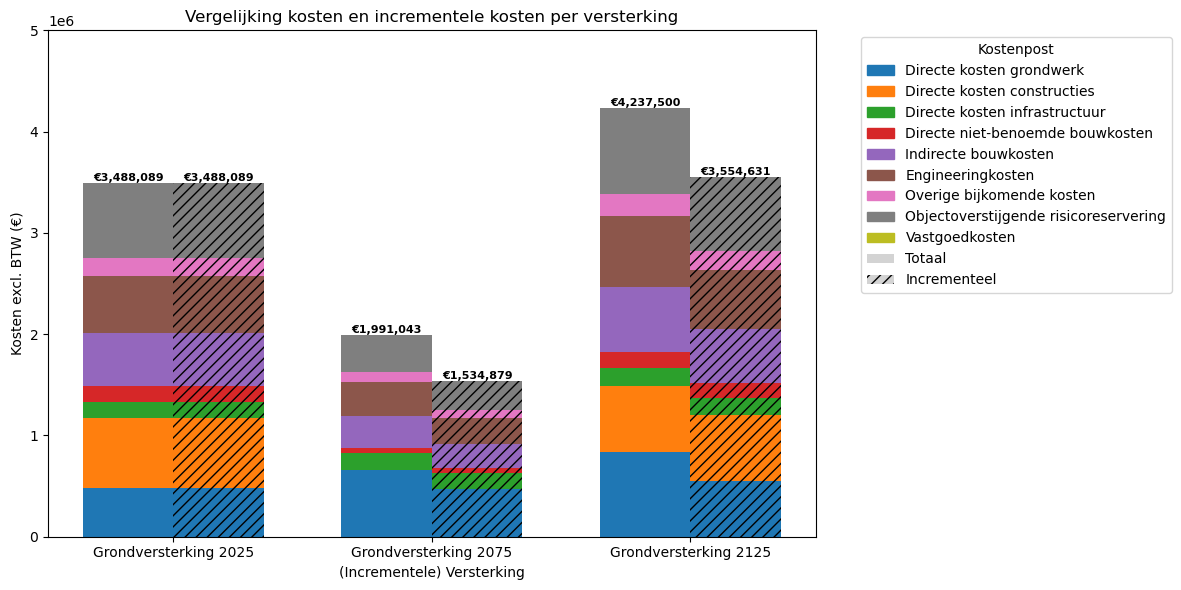

In [23]:
df_costs_T = df_all_costs.T
df_increments_T = df_all_increments.T

categories = df_costs_T.index          # cost categories (x-axis groups)
columns = df_costs_T.columns           # reinforcement variants
n = len(categories)
bar_width = 0.35
x = np.arange(n)

max_val = max(df_costs_T.sum(axis=1).max(), df_increments_T.sum(axis=1).max())
# Round up to nearest 0.5e6 with extra 0.5e6 margin for bar labels
y_max = (math.ceil(max_val / 0.5e6) + 1) * 0.5e6

fig, ax = plt.subplots(figsize=(12, 6))

# Use the same colormap for both stacks
colors = plt.cm.tab10.colors

# Draw stacked bars for df_all_costs (left of each group)
bottoms = np.zeros(n)
for i, col in enumerate(columns):
    values = df_costs_T[col].values
    ax.bar(x - bar_width / 2, values, width=bar_width, bottom=bottoms,
           color=colors[i % len(colors)], label=col)
    bottoms += values

# Add total label on top of each cost bar
for i, total in enumerate(df_costs_T.sum(axis=1)):
    ax.text(x[i] - bar_width / 2, bottoms[i], f"€{total:,.0f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold")

# Draw stacked bars for df_all_increments (right of each group)
bottoms = np.zeros(n)
for i, col in enumerate(columns):
    values = df_increments_T[col].values
    ax.bar(x + bar_width / 2, values, width=bar_width, bottom=bottoms,
           color=colors[i % len(colors)], hatch="///")
    bottoms += values

# Add total label on top of each increment bar
for i, total in enumerate(df_increments_T.sum(axis=1)):
    ax.text(x[i] + bar_width / 2, bottoms[i], f"€{total:,.0f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold")

# Legend: one entry per column (color), plus a hatch indicator
column_handles = [mpatches.Patch(color=colors[i % len(colors)], label=col)
                  for i, col in enumerate(columns)]
hatch_handles = [
    mpatches.Patch(facecolor="lightgrey", label="Totaal"),
    mpatches.Patch(facecolor="lightgrey", hatch="///", label="Incrementeel"),
]
ax.legend(handles=column_handles + hatch_handles,
          title="Kostenpost", bbox_to_anchor=(1.05, 1), loc="upper left")

ax.set_title("Vergelijking kosten en incrementele kosten per versterking")
ax.set_ylabel("Kosten excl. BTW (€)")
ax.set_xlabel("(Incrementele) Versterking")
ax.set_xticks(x)
ax.set_xticklabels(categories, rotation=0, ha="center")
ax.set_ylim(0, y_max)
plt.tight_layout()
plt.show()